## Trabajo Práctico: Redes Neuronales
El objetivo de este trabajo es desarrollar y evaluar modelos basados en redes neuronales,
incorporando técnicas de ablación para entender el impacto de diversas modificaciones en
el proceso de entrenamiento y en la capacidad de generalización del modelo. No se permite
usar librerías de machine learning como scikit-learn o PyTorch, a menos que sea pedido
explícitamente en el enunciado del ejercicio.

In [91]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import *
from src.plots import *
from src.neural_network import *
from src.improved_neural_network import *
from src.experiment import *
from src.utils import *

import torch
from src.pytorch_network import PyTorchNetwork

### 1. Análisis y Preprocesamiento de Datos
- El dataset que vamos a utilizar es similar a MNIST pero con caracteres japoneses.
- Son imágenes de 28 × 28 con 49 clases posibles.
- Examinar el dataset y visualizar al menos 3 imágenes. 
- Dividir el conjunto de datos en tres subconjuntos: Train, Validation y Test.
- Dividir todos los valores por 255, para que el máximo sea 1.

In [78]:
X_images = np.load("data/X_images.npy")
y_images = np.load("data/y_images.npy")

print("Forma de X_images:", X_images.shape)
print("Forma de y_images:", y_images.shape)
print("Número de clases únicas:", len(np.unique(y_images)))

Forma de X_images: (5000, 784)
Forma de y_images: (5000,)
Número de clases únicas: 49


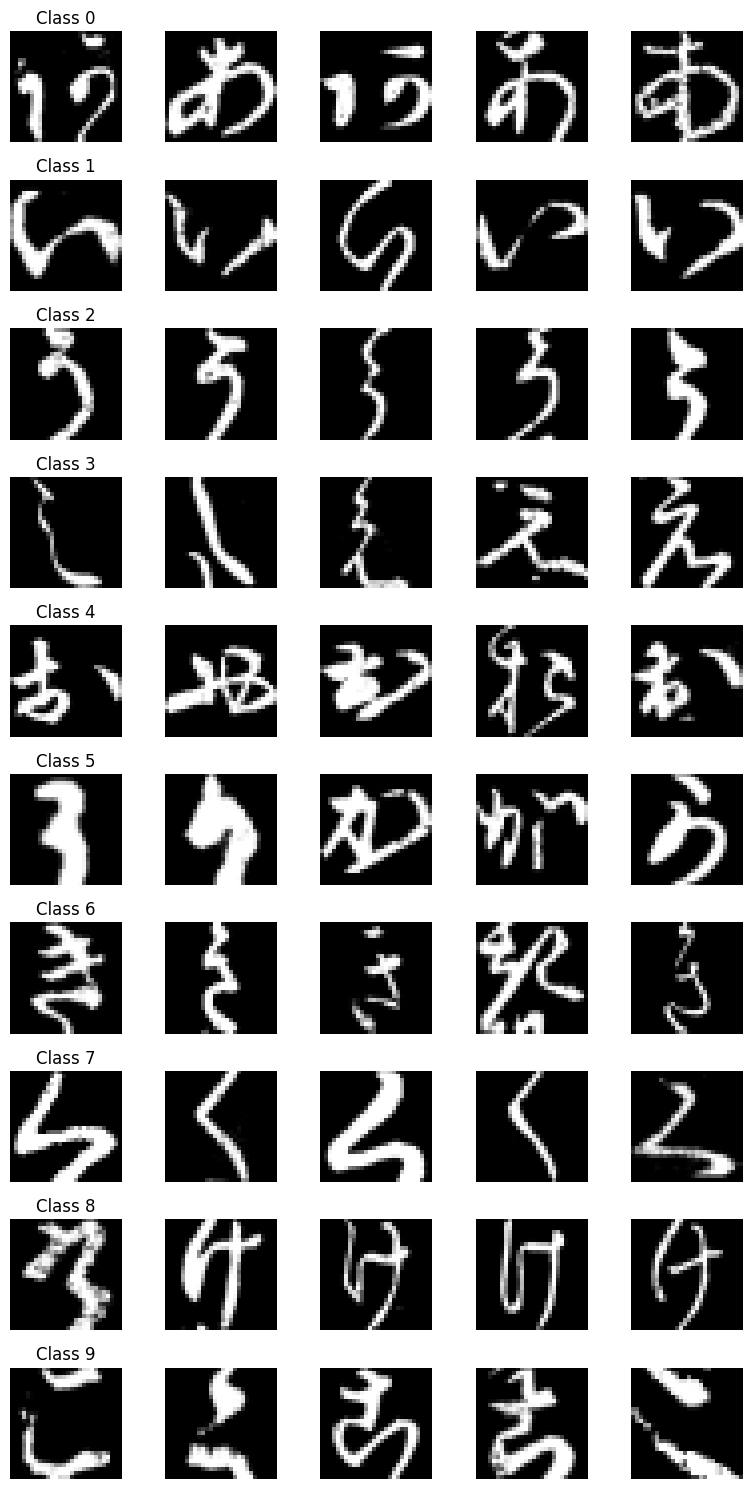

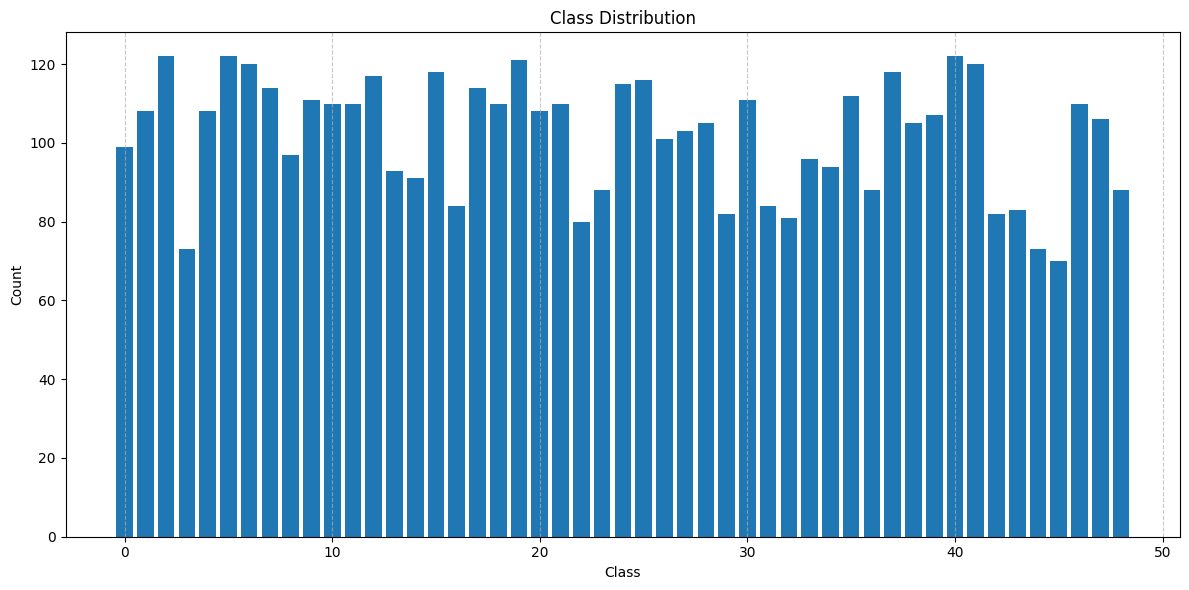

Most common class: 40 with 122 samples
Least common class: 45 with 70 samples
Class imbalance ratio (most common / least common): 1.74


In [39]:
visualize_samples(X_images, y_images, num_samples=5, num_classes=10, figsize=(8, 15))
plot_class_distribution(y_images)

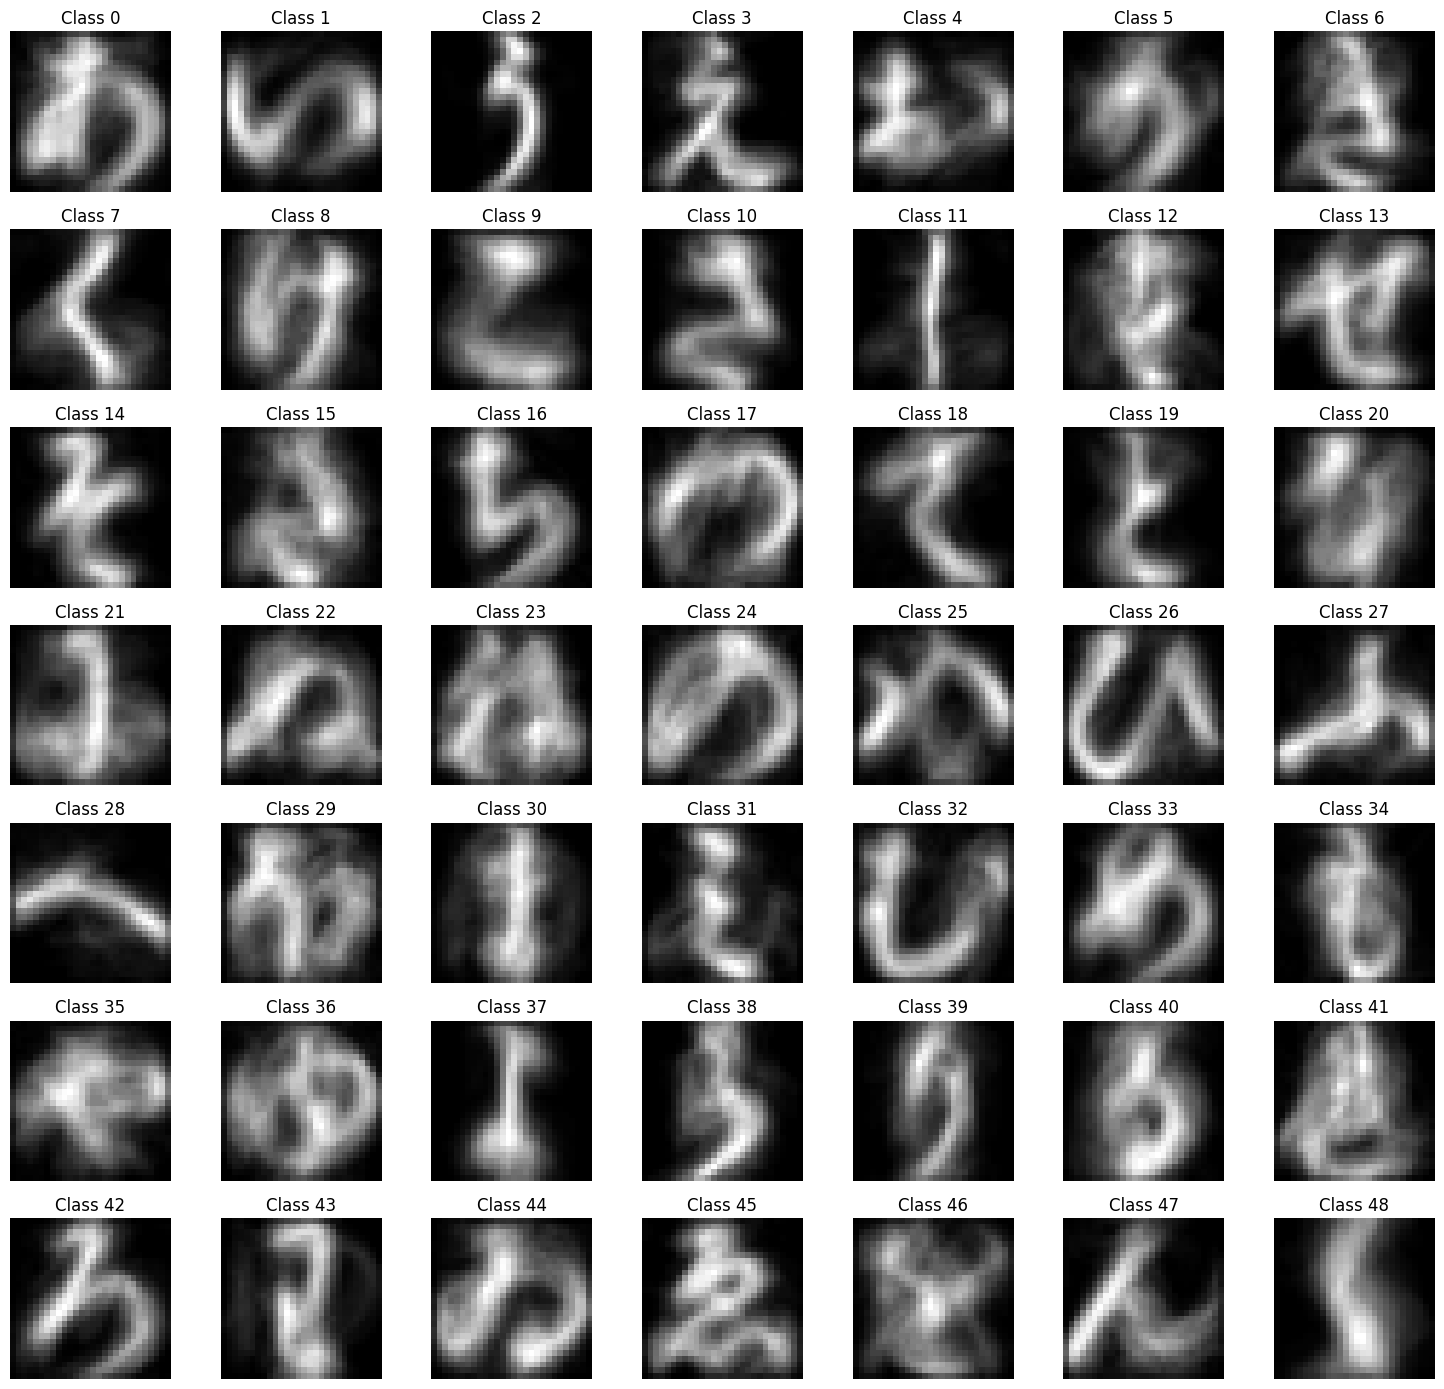

In [40]:
plot_class_averages(X_images, y_images, num_classes=49)

In [79]:
X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(
    X_images / 255.0 , y_images, train_ratio=0.8 * 0.8, val_ratio=0.8 * 0.2, test_ratio=0.2, random_state=42
)

print(f"X_train: {X_train.shape}, y_train: {len(y_train)}")
print(f"X_val: {X_val.shape}, y_val: {len(y_val)}")
print(f"X_test: {X_test.shape}, y_test: {len(y_test)}")
print(f"Rango de valores en X_train: [{X_train.min()}, {X_train.max()}]")

X_train: (3197, 784), y_train: 3197
X_val: (802, 784), y_val: 802
X_test: (1001, 784), y_test: 1001
Rango de valores en X_train: [0.0, 1.0]


### 2. Implementación y Entrenamiento de una Red Neuronal Básica
- Implementar una red neuronal con L capas ocultas cada con M (l) nodos confunción de activación ReLU (en las capas ocultas) y activación softmax para la capa de salida.
- Implementar un algoritmo para entrenar dicha red, mediante backpropagation y gradiente descendiente estándar, utilizando como función de costo la cross-entropy. 
NOTA: El algoritmo backpropagation debe sera adaptado para el caso de clasificación multi-clase con función de activación softmax para la capa de salida y función de costo cross-entropy.
- Entrenar una red neuronal con 2 capas ocultas, con 100 y 80 nodos respectivamente, y graficar la evolución de la función de costo (cross-entropy) sobre los conjuntos de entrenamiento y validación a lo largo de las épocas. Llamaremos a este modelo M0.
Reportar las siguientes métricas de performance, sobre los conjuntos de entrenamiento y validación, para el modelo base entrenado:
    - Accuracy
    - Cross-Entropy 
    - Matriz de Confusión

Epoch: [=================================================>] 100% - train_loss: 0.6248 - train_acc: 0.8661 - val_loss: 1.7288 - val_acc: 0.5736
Model successfully saved to modelos/model_M0.pkl


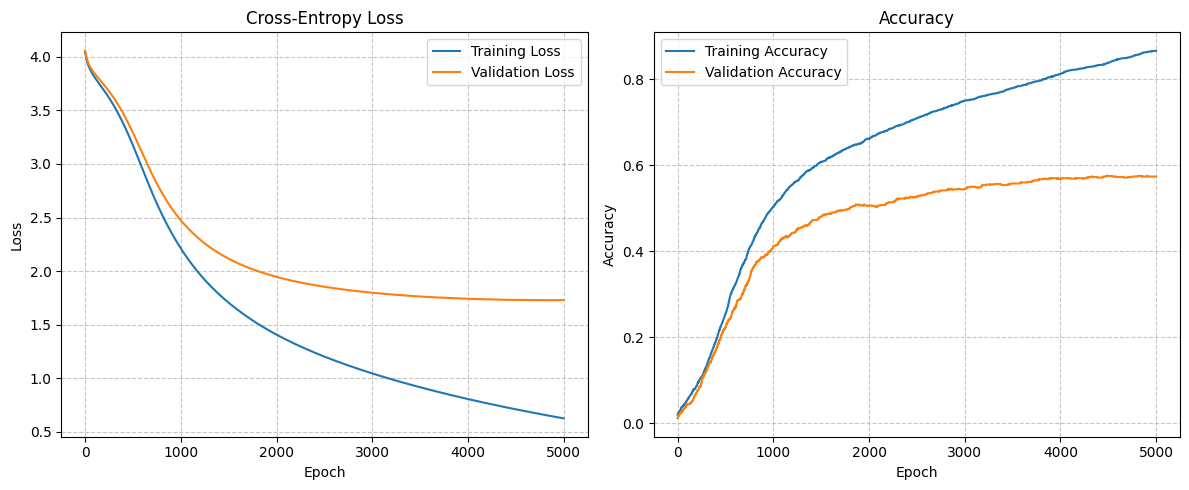

In [8]:
input_size = X_train.shape[1]
output_size = len(np.unique(y_train))
layer_sizes = [input_size, 100, 80, output_size]

model_M0 = NeuralNetwork(layer_sizes, learning_rate=0.01)

history_M0 = model_M0.train(X_train, y_train, X_val, y_val, epochs=5000)
save_model(model_M0, "model_M0.pkl")

plot_learning_curves(history_M0)

In [9]:
train_accuracy, train_loss, train_pred = model_M0.evaluate(X_train, y_train)
val_accuracy, val_loss, val_pred = model_M0.evaluate(X_val, y_val)

print(f"Performance Metrics for Model M0:")
print(f"Training Set - Accuracy: {train_accuracy:.4f}, Cross-Entropy: {train_loss:.4f}")
print(f"Validation Set - Accuracy: {val_accuracy:.4f}, Cross-Entropy: {val_loss:.4f}")

Performance Metrics for Model M0:
Training Set - Accuracy: 0.8661, Cross-Entropy: 0.6248
Validation Set - Accuracy: 0.5736, Cross-Entropy: 1.7288


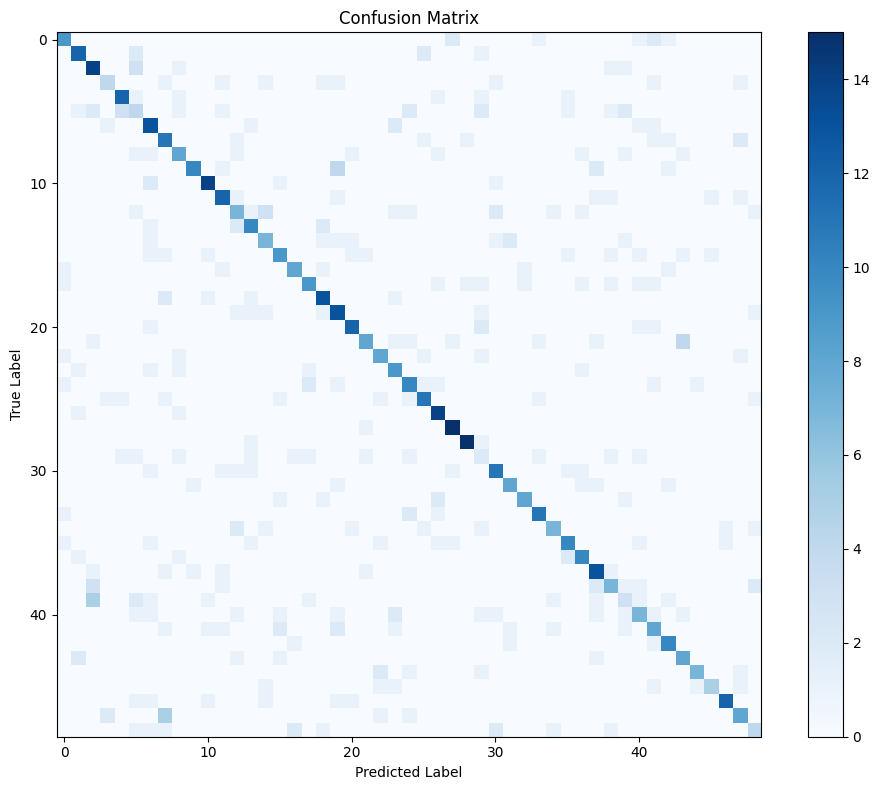

In [10]:
conf_matrix = model_M0.confusion_matrix(y_val, val_pred)
plot_confusion_matrix(conf_matrix)

### 3. Implementación y Entrenamiento de una Red Neuronal Avanzada
- Implementar las siguientes mejoras al algoritmo de entrenamiento, y para cada una reportar el efecto observado sobre el tiempo de entrenamiento y la performance del modelo resultante.
    - Rate scheduling lineal (con saturación) y exponencial.
    - Mini-batch stochastic gradient descent.
    - Optimizador ADAM.
    - Regularización L2.
    - Regularización mediante early stopping.
    - OPCIONAL: Regularización mediante dropout.
    - OPCIONAL: batch normalization.
- Explorar cambios en la arquitectura de la red (es decir, la cantidad de capas ocultas y unidades ocultas por capa), y los hiperparámetros (cada uno de los items en la lista anterior tiene una serie de parámetros que podemos variar), y determinar la configuración que funcione mejor (menor error de validación).
Llamaremos a este modelo M1.

In [80]:
input_size = X_train.shape[1] 
output_size = len(np.unique(y_train))
layer_sizes = [input_size, 100, 80, output_size]

print(f"Network architecture: {input_size} inputs → {layer_sizes[1]} neurons → {layer_sizes[2]} neurons → {output_size} outputs")

Network architecture: 784 inputs → 100 neurons → 80 neurons → 49 outputs


In [81]:
experiments = [
    {
        'name': 'Baseline (SGD)',
        'learning_rate': 0.01,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': None, 
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    }, {
        'name': 'Linear Rate Scheduling',
        'learning_rate': 0.01,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': None,
        'optimizer': 'sgd',
        'lr_schedule': 'linear',
        'early_stopping_patience': None
    },{
        'name': 'Exponential Rate Scheduling',
        'learning_rate': 0.01,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': None,
        'optimizer': 'sgd',
        'lr_schedule': 'exponential',
        'early_stopping_patience': None
    },{
        'name': 'Mini-batch SGD',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': 64, 
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    },{
        'name': 'ADAM Optimizer',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 500,
        'batch_size': 64,
        'optimizer': 'adam',
        'lr_schedule': None,
        'early_stopping_patience': None
    },{
        'name': 'L2 Regularization',
        'learning_rate': 0.001,
        'l2_lambda': 0.001,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 1000,
        'batch_size': 64,
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    },{
        'name': 'Early Stopping',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 4000,
        'batch_size': 64,
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': 10  
    },{
        'name': 'Dropout',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.2,  
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': 64,
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    },{
        'name': 'Batch Normalization',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': True,  
        'epochs': 750,
        'batch_size': 64,
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    },{
        'name': 'Combined Improvements',
        'learning_rate': 0.001,
        'l2_lambda': 0.0005,  
        'dropout_rate': 0.2,  
        'use_batch_norm': True,
        'epochs': 4000,
        'batch_size': 64,
        'optimizer': 'adam',
        'lr_schedule': 'exponential', 
        'early_stopping_patience': 15 
    }
]

In [82]:
results = run_experiments(
    X_train, y_train, 
    X_val, y_val, 
    ImprovedNeuralNetwork, 
    layer_sizes, 
    experiments)


Running experiment: Baseline (SGD)
Epoch: [=================================================>] 100% - train_loss: 1.4066 - train_acc: 0.6637 - val_loss: 1.9457 - val_acc: 0.5075 - lr: 0.0100
Running experiment: Linear Rate Scheduling
Epoch: [=================================================>] 100% - train_loss: 1.6093 - train_acc: 0.6090 - val_loss: 2.0218 - val_acc: 0.4913 - lr: 0.0050
Running experiment: Exponential Rate Scheduling
Epoch: [=================================================>] 100% - train_loss: 1.3299 - train_acc: 0.6741 - val_loss: 1.8751 - val_acc: 0.5237 - lr: 0.0090
Running experiment: Mini-batch SGD
Epoch: [=================================================>] 100% - train_loss: 0.1751 - train_acc: 0.9869 - val_loss: 1.9276 - val_acc: 0.5860 - lr: 0.0010
Running experiment: ADAM Optimizer
Epoch: [=================================================>] 100% - train_loss: 0.0000 - train_acc: 1.0000 - val_loss: 5.3701 - val_acc: 0.6297 - lr: 0.0010
Running experiment: L2 

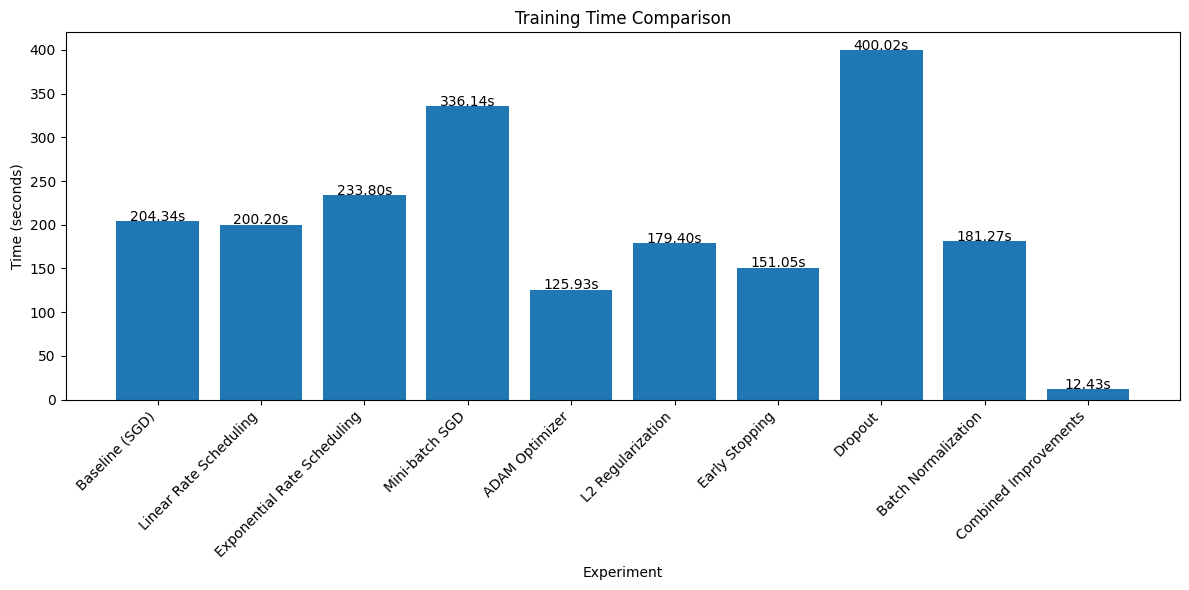

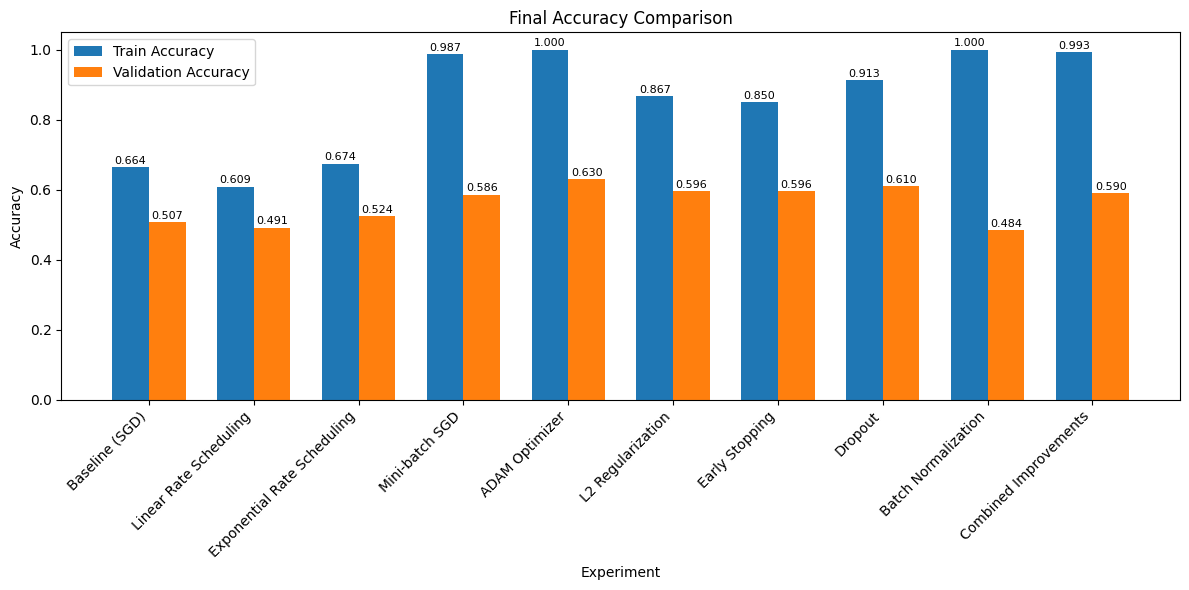

In [83]:
compare_training_times(results)
compare_final_metrics(results)

In [84]:
sorted_results = sorted(results, key=lambda x: x['final_val_accuracy'], reverse=True)

best_result = sorted_results[0]
print(f"\nBest model: {best_result['name']}")
print(f"Validation accuracy: {best_result['final_val_accuracy']:.4f}")

second_best_result = sorted_results[1]
print(f"\nSecond best model: {second_best_result['name']}")
print(f"Validation accuracy: {second_best_result['final_val_accuracy']:.4f}")


Best model: ADAM Optimizer
Validation accuracy: 0.6297

Second best model: Dropout
Validation accuracy: 0.6097


In [85]:
architectures = [
    {
        'name': 'Single Hidden Layer (200)',
        'layer_sizes': [input_size, 200, output_size]
    },{
        'name': 'Two Hidden Layers (100, 80)',
        'layer_sizes': [input_size, 100, 80, output_size]
    },{
        'name': 'Three Hidden Layers (120, 80, 60)',
        'layer_sizes': [input_size, 120, 80, 60, output_size]
    },{
        'name': 'Wide Network (200, 150)',
        'layer_sizes': [input_size, 200, 150, output_size]
    },{
        'name': 'Deep Network (100, 80, 60, 40)',
        'layer_sizes': [input_size, 100, 80, 60, 40, output_size]
    }
]

In [93]:
architecture_results = run_architecture_experiments(
    architectures=architectures,
    configuration=best_result,
    NeuralNetwork=ImprovedNeuralNetwork,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

Testing architecture: Single Hidden Layer (200)
Epoch: [=================================================>] 100% - train_loss: 0.0000 - train_acc: 1.0000 - val_loss: 4.4118 - val_acc: 0.6521 - lr: 0.0010
Testing architecture: Two Hidden Layers (100, 80)
Epoch: [=================================================>] 100% - train_loss: 0.0000 - train_acc: 1.0000 - val_loss: 5.4709 - val_acc: 0.6135 - lr: 0.0010
Testing architecture: Three Hidden Layers (120, 80, 60)
Epoch: [=================================================>] 100% - train_loss: 0.0000 - train_acc: 1.0000 - val_loss: 5.8013 - val_acc: 0.6272 - lr: 0.0010
Testing architecture: Wide Network (200, 150)
Epoch: [=================================================>] 100% - train_loss: 0.0000 - train_acc: 1.0000 - val_loss: 4.6417 - val_acc: 0.6633 - lr: 0.0010
Testing architecture: Deep Network (100, 80, 60, 40)
Epoch: [=================================================>] 100% - train_loss: 0.0000 - train_acc: 1.0000 - val_loss: 7.004

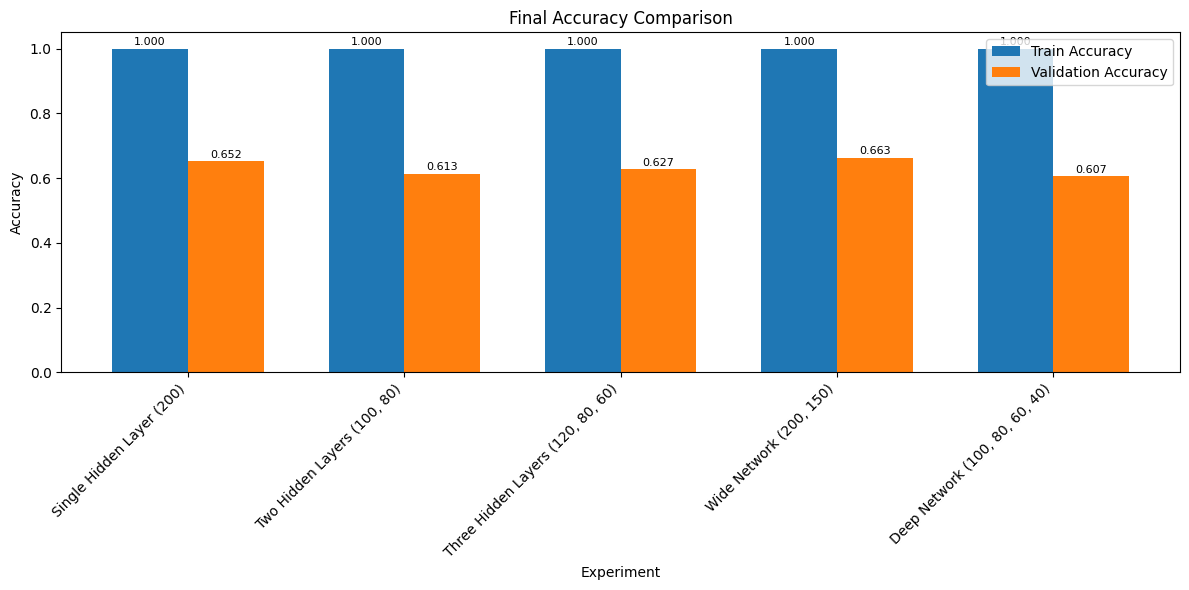


Best architecture: Wide Network (200, 150)
Validation accuracy: 0.6633


In [94]:
compare_final_metrics(architecture_results)

best_arch_result = max(architecture_results, key=lambda x: x['final_val_accuracy'])
print(f"\nBest architecture: {best_arch_result['name']}")
print(f"Validation accuracy: {best_arch_result['final_val_accuracy']:.4f}")

In [96]:
learning_rates_to_test = [0.0001, 0.0005, 0.001, 0.005, 0.01]

lr_tuning_experiments = []

config = {
        'learning_rate': 0.001,
        'l2_lambda': 0.0,  
        'dropout_rate': 0.3,  
        'use_batch_norm': False,
        'epochs': 250,
        'batch_size': 64,
        'optimizer': 'adam',
        'lr_schedule': None, 
        'early_stopping_patience': 20 
    }

for lr_value in learning_rates_to_test:
    lr_tuning_experiments.append(config.copy())
    lr_tuning_experiments[-1]['learning_rate'] = lr_value
    lr_tuning_experiments[-1]['name'] = f"LR_{lr_value}"

lr_tuning_results = run_experiments(X_train, y_train, X_val, y_val, ImprovedNeuralNetwork, best_arch_result['layer_sizes'], lr_tuning_experiments)

best_lr_tuned_model = max(lr_tuning_results, key=lambda x: x.get('final_val_accuracy', -float('inf')))


Running experiment: LR_0.0001
Epoch: [=============================>                    ] 60% - train_loss: 0.2136 - train_acc: 0.9687 - val_loss: 1.3946 - val_acc: 0.6521 - lr: 0.0001
Early stopping triggered at epoch 150


Running experiment: LR_0.0005
Epoch: [=========>                                        ] 19% - train_loss: 0.0722 - train_acc: 0.9953 - val_loss: 1.4249 - val_acc: 0.6683 - lr: 0.0005
Early stopping triggered at epoch 49


Running experiment: LR_0.001
Epoch: [======>                                           ] 14% - train_loss: 0.0336 - train_acc: 0.9975 - val_loss: 1.6166 - val_acc: 0.6584 - lr: 0.0010
Early stopping triggered at epoch 35


Running experiment: LR_0.005
Epoch: [=====>                                            ] 12% - train_loss: 0.0984 - train_acc: 0.9834 - val_loss: 1.8146 - val_acc: 0.6334 - lr: 0.0050
Early stopping triggered at epoch 30


Running experiment: LR_0.01
Epoch: [=====>                                            ] 12% - train_loss

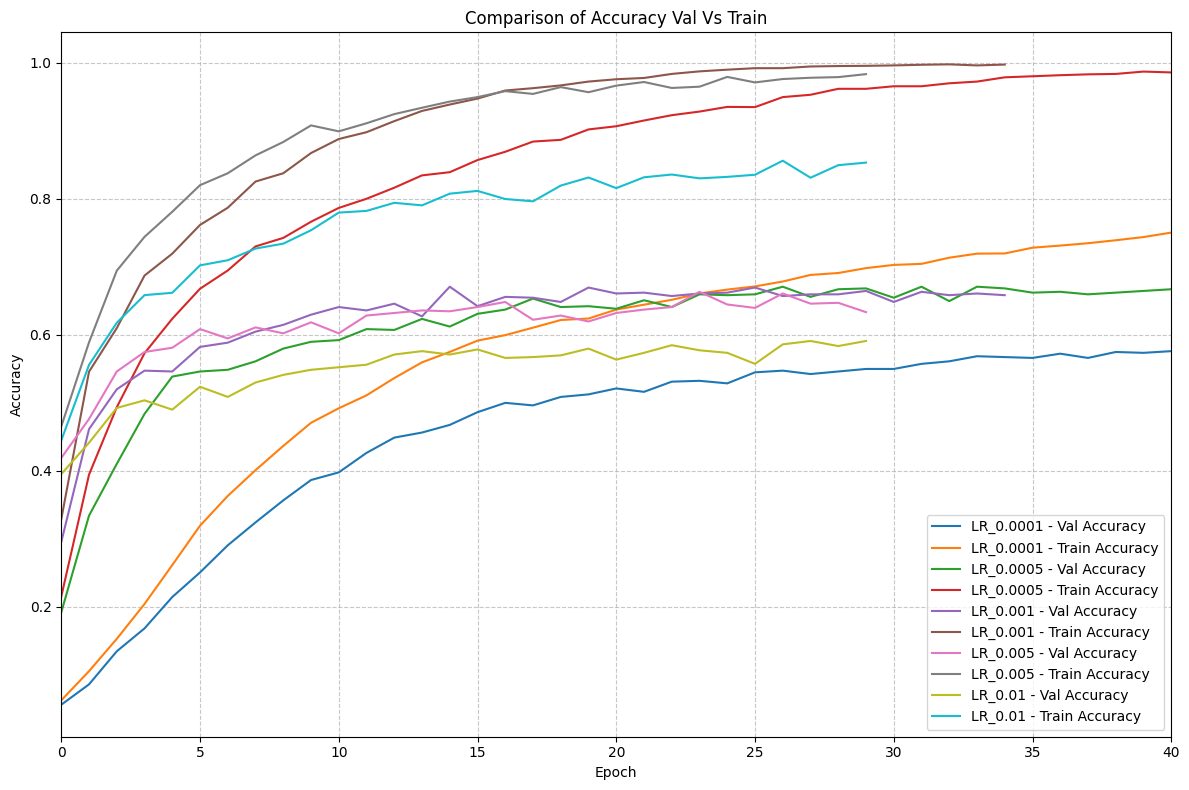

In [114]:
plot_experiment_results(lr_tuning_results, metric='accuracy_val_vs_train', x_lim=(0,40))

In [98]:
schedules_to_test = ['exponential', 'linear', None]

schedule_tuning_experiments = []

best_lr = best_lr_tuned_model['learning_rate']
config['learning_rate']= best_lr

for sched in schedules_to_test:
    schedule_tuning_experiments.append(config.copy())
    schedule_tuning_experiments[-1]['lr_schedule'] = sched
    schedule_tuning_experiments[-1]['name'] = f"LRSchedule_{sched}"

schedule_tuning_results = run_experiments(
    X_train, y_train, X_val, y_val,
    ImprovedNeuralNetwork,
    best_arch_result['layer_sizes'],
    schedule_tuning_experiments
)

best_sched_tuned_model = max(schedule_tuning_results, key=lambda x: x.get('final_val_accuracy', -float('inf')))


Running experiment: LRSchedule_exponential
Epoch: [=========>                                        ] 20% - train_loss: 0.0711 - train_acc: 0.9950 - val_loss: 1.4675 - val_acc: 0.6496 - lr: 0.0005
Early stopping triggered at epoch 50


Running experiment: LRSchedule_linear
Epoch: [===========>                                      ] 23% - train_loss: 0.0564 - train_acc: 0.9959 - val_loss: 1.4407 - val_acc: 0.6559 - lr: 0.0004
Early stopping triggered at epoch 59


Running experiment: LRSchedule_None
Epoch: [========>                                         ] 18% - train_loss: 0.0898 - train_acc: 0.9909 - val_loss: 1.4210 - val_acc: 0.6771 - lr: 0.0005
Early stopping triggered at epoch 46



In [99]:
l2_values_to_test = [0.0, 0.005, 0.01, 0.05, 0.1, 0.5]

l2_tuning_experiments = []

best_sched = best_sched_tuned_model['lr_schedule']
config['lr_schedule'] = best_sched

config['early_stopping_patience'] = 20

for l2_value in l2_values_to_test:
    l2_tuning_experiments.append(config.copy())
    l2_tuning_experiments[-1]['l2_lambda'] = l2_value
    l2_tuning_experiments[-1]['name'] = f"L2_{l2_value}"

l2_tuning_results = run_experiments(
    X_train, y_train, X_val, y_val,
    ImprovedNeuralNetwork,
    best_arch_result['layer_sizes'],
    l2_tuning_experiments
)

best_l2_tuned_model = max(l2_tuning_results, key=lambda x: x.get('final_val_accuracy', -float('inf')))


Running experiment: L2_0.0
Epoch: [==========>                                       ] 22% - train_loss: 0.0491 - train_acc: 0.9962 - val_loss: 1.4591 - val_acc: 0.6521 - lr: 0.0005
Early stopping triggered at epoch 55


Running experiment: L2_0.005
Epoch: [=========>                                        ] 20% - train_loss: 0.0726 - train_acc: 0.9947 - val_loss: 1.4782 - val_acc: 0.6347 - lr: 0.0005
Early stopping triggered at epoch 50


Running experiment: L2_0.01
Epoch: [=========>                                        ] 19% - train_loss: 0.0773 - train_acc: 0.9953 - val_loss: 1.4803 - val_acc: 0.6521 - lr: 0.0005
Early stopping triggered at epoch 49


Running experiment: L2_0.05
Epoch: [===========>                                      ] 24% - train_loss: 0.0730 - train_acc: 0.9978 - val_loss: 1.4500 - val_acc: 0.6771 - lr: 0.0005
Early stopping triggered at epoch 60


Running experiment: L2_0.1
Epoch: [==============>                                   ] 30% - train_loss: 0.0863

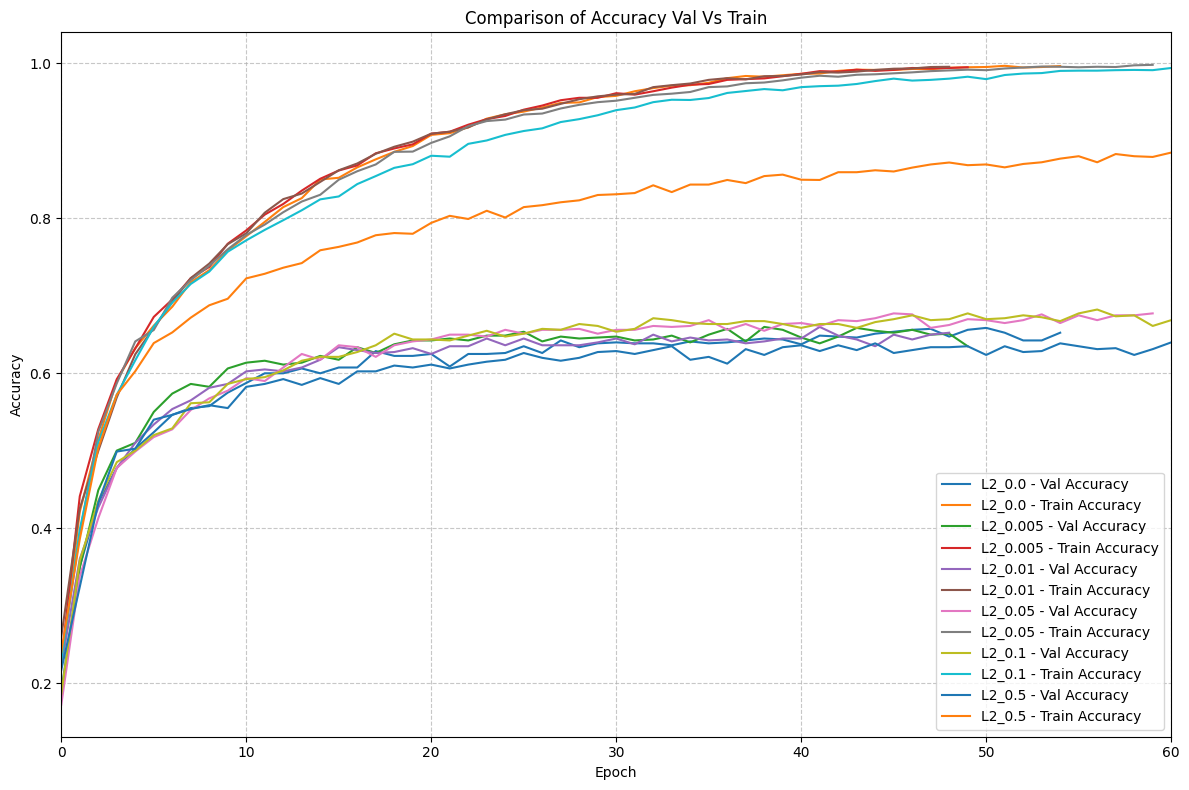

Best L2-tuned model: L2_0.05
Validation accuracy: 0.6771


In [100]:
plot_experiment_results(l2_tuning_results, metric='accuracy_val_vs_train', x_lim=(0,60))
print(f"Best L2-tuned model: {best_l2_tuned_model['name']}")
print(f"Validation accuracy: {best_l2_tuned_model['final_val_accuracy']:.4f}")

In [101]:
dropout_values_to_test = [0.1, 0.2, 0.3]

dropout_tuning_experiments = []

best_l2 = best_l2_tuned_model['l2_lambda']
config['l2_lambda'] = best_l2

for dropout_value in dropout_values_to_test:
    dropout_tuning_experiments.append(config.copy())
    dropout_tuning_experiments[-1]['dropout_rate'] = dropout_value
    dropout_tuning_experiments[-1]['name'] = f"Dropout_{dropout_value}"

dropout_tuning_results = run_experiments(
    X_train, y_train, X_val, y_val,
    ImprovedNeuralNetwork,
    best_arch_result['layer_sizes'],
    dropout_tuning_experiments
)

best_dropout_tuned_model = max(dropout_tuning_results, key=lambda x: x.get('final_val_accuracy', -float('inf')))


Running experiment: Dropout_0.1
Epoch: [======>                                           ] 14% - train_loss: 0.0809 - train_acc: 0.9984 - val_loss: 1.5127 - val_acc: 0.6596 - lr: 0.0005
Early stopping triggered at epoch 36


Running experiment: Dropout_0.2
Epoch: [========>                                         ] 18% - train_loss: 0.0758 - train_acc: 0.9966 - val_loss: 1.4667 - val_acc: 0.6671 - lr: 0.0005
Early stopping triggered at epoch 47


Running experiment: Dropout_0.3
Epoch: [==========>                                       ] 22% - train_loss: 0.0853 - train_acc: 0.9953 - val_loss: 1.4289 - val_acc: 0.6796 - lr: 0.0005
Early stopping triggered at epoch 57



In [102]:
batch_sizes_to_test = [16, 32, 64, 128]
batch_size_tuning_experiments = []

best_dropout = best_dropout_tuned_model['dropout_rate']

config['dropout_rate'] = best_dropout

for bs_value in batch_sizes_to_test:
    batch_size_tuning_experiments.append(config.copy())
    batch_size_tuning_experiments[-1]['batch_size'] = bs_value
    batch_size_tuning_experiments[-1]['name'] = f"BatchSize_{bs_value}"

batch_size_tuning_results = run_experiments(
    X_train, y_train, X_val, y_val,
    ImprovedNeuralNetwork,
    best_arch_result['layer_sizes'],
    batch_size_tuning_experiments
)

best_bs_tuned_model = max(batch_size_tuning_results, key=lambda x: x.get('final_val_accuracy', -float('inf')))


Running experiment: BatchSize_16
Epoch: [=========>                                        ] 19% - train_loss: 0.1881 - train_acc: 0.9815 - val_loss: 1.3409 - val_acc: 0.6721 - lr: 0.0005
Early stopping triggered at epoch 48


Running experiment: BatchSize_32
Epoch: [=========>                                        ] 20% - train_loss: 0.0900 - train_acc: 0.9962 - val_loss: 1.4041 - val_acc: 0.6496 - lr: 0.0005
Early stopping triggered at epoch 52


Running experiment: BatchSize_64
Epoch: [===========>                                      ] 24% - train_loss: 0.0755 - train_acc: 0.9966 - val_loss: 1.4600 - val_acc: 0.6521 - lr: 0.0005
Early stopping triggered at epoch 60


Running experiment: BatchSize_128
Epoch: [=============>                                    ] 27% - train_loss: 0.1000 - train_acc: 0.9931 - val_loss: 1.4594 - val_acc: 0.6559 - lr: 0.0005
Early stopping triggered at epoch 68



In [103]:
top_models = sorted(results + architecture_results + l2_tuning_results + lr_tuning_results + dropout_tuning_results + batch_size_tuning_results + schedule_tuning_results, 
                    key=lambda x: x.get('final_val_accuracy', 0), reverse=True)[:5]

summary_df = pd.DataFrame([{
    'Nombre': m['name'],
    'Val Accuracy': round(m.get('final_val_accuracy', 0), 4),
    'Train Accuracy': round(m.get('final_train_accuracy', 0), 4),
    'Val Loss': round(m.get('final_val_loss', 0), 4),
    'Arquitectura': m.get('layer_sizes', 'N/A'),
    'LR': m.get('learning_rate', 'N/A'),
    'L2': m.get('l2_lambda', 'N/A'),
    'Dropout': m.get('dropout_rate', 'N/A'),
    'Batch Size': m.get('batch_size', 'N/A'),
    
} for m in top_models])

summary_df.style.set_caption("Top 5 modelos por performance en validación")


,Nombre,Val Accuracy,Train Accuracy,Val Loss,Arquitectura,LR,L2,Dropout,Batch Size
0,Dropout_0.3,0.679600,0.995300,1.428900,"[784, 200, 150, 49]",0.000500,0.050000,0.300000,64
1,L2_0.05,0.677100,0.997800,1.450000,"[784, 200, 150, 49]",0.000500,0.050000,0.300000,64
2,LRSchedule_None,0.677100,0.990900,1.421000,"[784, 200, 150, 49]",0.000500,0.000000,0.300000,64
3,L2_0.1,0.672100,0.998100,1.392400,"[784, 200, 150, 49]",0.000500,0.100000,0.300000,64
4,BatchSize_16,0.672100,0.981500,1.340900,"[784, 200, 150, 49]",0.000500,0.050000,0.300000,16



Final model performance on test set:
Test loss: 1.9524, test accuracy: 0.5295
Configuración Completa:
  learning_rate: 0.0005
  l2_lambda: 0.0
  dropout_rate: 0.3
  use_batch_norm: False
  epochs: 250
  batch_size: 64
  optimizer: adam
  lr_schedule: None
  early_stopping_patience: 20
  name: LRSchedule_None
  layer_sizes: [784, 200, 150, 49]
  final_train_loss: 0.08977278331735698
  final_train_accuracy: 0.9909289959336879
  final_val_loss: 1.4210336878404275
  final_val_accuracy: 0.6770573566084788
  training_time: 21.94993543624878


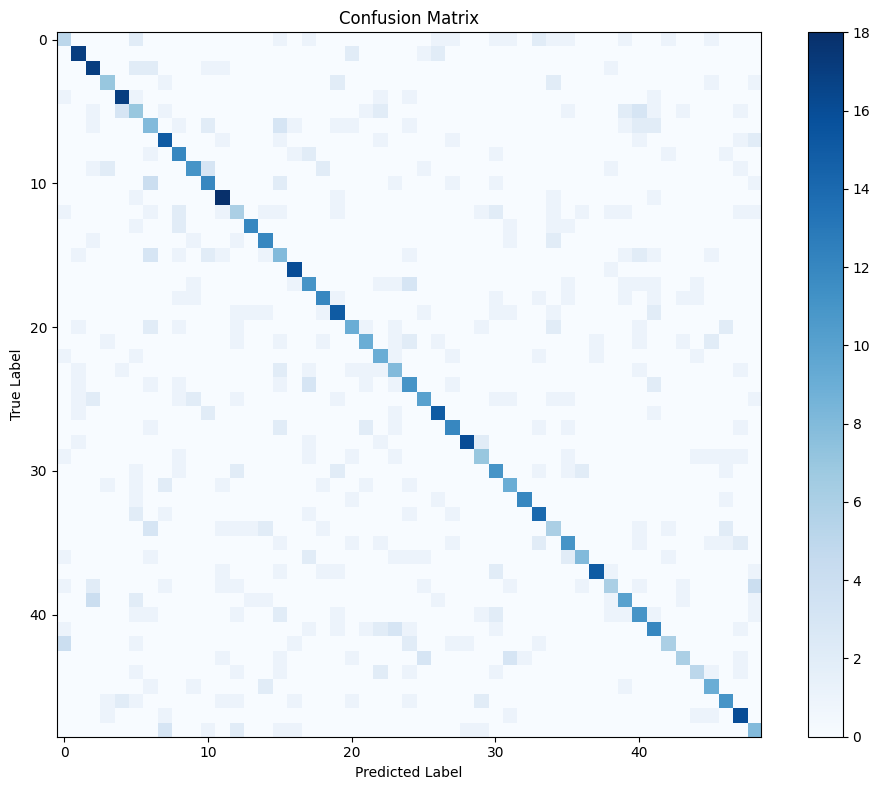

Model successfully saved to modelos/model_M1.pkl


In [107]:
final_model = best_sched_tuned_model['model']
test_accuracy, test_loss, y_pred_test = final_model.evaluate(X_test, y_test)

print(f"\nFinal model performance on test set:")
print(f"Test loss: {test_loss:.4f}, test accuracy: {test_accuracy:.4f}")

print(f"Configuración Completa:")
for key, value in best_sched_tuned_model.items():
    if key not in ['history', 'model']:
        print(f"  {key}: {value}")

conf_matrix = final_model.confusion_matrix(y_test, y_pred_test)
plot_confusion_matrix(conf_matrix)

model_M1 = final_model
save_model(model_M1, "model_M1.pkl")

### 4. Desarrollo de una Red Neuronal con PyTorch
- Utilizando PyTorch, entrenar una red neuronal con la arquitectura y los hiperparámetros hallados en el ejercicio anterior. Llmaremos a este modelo M2.
- Utilizando PyTorch, explorar cambios en la cantidad de capas ocultas y unidades ocultas por capa, y determinar la configuración que funcione mejor. LLamaremos a este modelo M3.
- Utilizando PyTorch, encontrar una arquitectura (capas ocultas y unidades por
capa) que produzca overfitting. Llamaremos a este modelo M4.
Comparar la performance sobre el conjunto de test de los siguientes cuatro modelos:
    1. El modelo base de implementación propia (M0).
    2. La mejor arquitectura obtenida con la implementación propia (M1).
    3. Modelo en PyTorch, usando la misma arquiterctura e hiperparámetros que en la implementación propia (M2).
    4. La mejor arquitectura obtenida en PyTorch (M3).
    5. Una arquitectura en PyTorch con sobreajuste (M4).

In [74]:
print("\n4.a) Cargando el modelo base (M0) de implementación propia...")
model_M0 = load_model("model_M0.pkl")

test_acc_M0, test_loss_M0, test_pred_M0 = model_M0.evaluate(X_test, y_test)
print(f"Modelo M0 en test: Accuracy={test_acc_M0:.4f}, Loss={test_loss_M0:.4f}")


4.a) Cargando el modelo base (M0) de implementación propia...
Model successfully loaded from modelos/model_M0.pkl
Modelo M0 en test: Accuracy=0.5814, Loss=1.8024


In [75]:
print("\n4.b) Cargando la mejor arquitectura de implementación propia (M1)...")
model_M1 = load_model("model_M1.pkl")

test_acc_M1, test_loss_M1, test_pred_M1 = model_M1.evaluate(X_test, y_test)
print(f"Modelo M1 en test: Accuracy={test_acc_M1:.4f}, Loss={test_loss_M1:.4f}")


4.b) Cargando la mejor arquitectura de implementación propia (M1)...
Model successfully loaded from modelos/model_M1.pkl
Modelo M1 en test: Accuracy=0.5345, Loss=2.0633


In [108]:
print("\n4.c) Implementando modelo en PyTorch con misma arquitectura (M2)...")
model_M2 = PyTorchNetwork(
    layer_sizes=layer_sizes,
    learning_rate=0.0005,
    l2_lambda=0.0,
    dropout_rate=0.3
)

print("Entrenando modelo M2...")
history_M2 = model_M2.train(
    X_train, y_train, X_val, y_val,
    epochs=500, batch_size=64,
    early_stopping_patience=20,
    verbose=1
)

save_model(model_M2, "model_M2.pkl")

test_acc_M2, test_loss_M2, test_pred_M2 = model_M2.evaluate(X_test, y_test)
print(f"Modelo M2 en test: Accuracy={test_acc_M2:.4f}, Loss={test_loss_M2:.4f}")


4.c) Implementando modelo en PyTorch con misma arquitectura (M2)...
Entrenando modelo M2...
Epoch: [=======>                                          ] 15% - train_loss: 0.7468 - train_acc: 0.7745 - val_loss: 1.6049 - val_acc: 0.6135
Early stopping triggered at epoch 76

Model successfully saved to modelos/model_M2.pkl
Modelo M2 en test: Accuracy=0.6004, Loss=1.7044


In [14]:
print("\n4.d) Explorando diferentes arquitecturas con PyTorch...")

architectures = [
    {'name': 'One Hidden Layer (200)', 'layer_sizes': [input_size, 200, output_size]},
    {'name': 'Two Hidden Layers (100, 80)', 'layer_sizes': [input_size, 100, 80, output_size]},
    {'name': 'Three Hidden Layers (120, 80, 60)', 'layer_sizes': [input_size, 120, 80, 60, output_size]},
    {'name': 'Wide Network (200, 150)', 'layer_sizes': [input_size, 200, 150, output_size]},
    {'name': 'Deep Network (100, 80, 60, 40)', 'layer_sizes': [input_size, 100, 80, 60, 40, output_size]}
]

config = {
    'learning_rate': 0.001,
    'l2_lambda': 0.0005,
    'dropout_rate': 0.2,
    'epochs': 1000,
    'batch_size': 64,
    'early_stopping_patience': 15
}

architecture_results = run_architecture_experiments(
    architectures=architectures,
    configuration=config,
    NeuralNetwork=PyTorchNetwork,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)


4.d) Explorando diferentes arquitecturas con PyTorch...
Testing architecture: One Hidden Layer (200)
Epoch: [=>                                                ] 4% - train_loss: 0.1739 - train_acc: 0.9756 - val_loss: 1.5297 - val_acc: 0.6434
Early stopping triggered at epoch 40

Testing architecture: Two Hidden Layers (100, 80)
Epoch: [=>                                                ] 4% - train_loss: 0.5485 - train_acc: 0.8470 - val_loss: 1.5695 - val_acc: 0.6284
Early stopping triggered at epoch 42

Testing architecture: Three Hidden Layers (120, 80, 60)
Epoch: [=>                                                ] 3% - train_loss: 0.7425 - train_acc: 0.7739 - val_loss: 1.7486 - val_acc: 0.5985
Early stopping triggered at epoch 37

Testing architecture: Wide Network (200, 150)
Epoch: [=>                                                ] 3% - train_loss: 0.2619 - train_acc: 0.9296 - val_loss: 1.6167 - val_acc: 0.6521
Early stopping triggered at epoch 31

Testing architecture: Deep Net

In [62]:
print("\n4.d) Explorando diferentes arquitecturas con PyTorch...")

architectures = [
    {'name': 'One Hidden Layer (200)', 'layer_sizes': [input_size, 200, output_size]},
    {'name': 'One Hidden Layer (300)', 'layer_sizes': [input_size, 300, output_size]},
    {'name': 'Two Hidden Layers (100, 80)', 'layer_sizes': [input_size, 100, 80, output_size]},
    {'name': 'Two Hidden Layers (256, 128)', 'layer_sizes': [input_size, 256, 128, output_size]},
    {'name': 'Three Hidden Layers (120, 80, 60)', 'layer_sizes': [input_size, 120, 80, 60, output_size]},
    {'name': 'Three Hidden Layers (300, 200, 100)', 'layer_sizes': [input_size, 300, 200, 100, output_size]},
    {'name': 'Four Hidden Layers (150, 120, 80, 60)', 'layer_sizes': [input_size, 150, 120, 80, 60, output_size]},
    {'name': 'Four Hidden Layers (256, 192, 128, 64)', 'layer_sizes': [input_size, 256, 192, 128, 64, output_size]},
    {'name': 'Wide Network (200, 150)', 'layer_sizes': [input_size, 200, 150, output_size]},
    {'name': 'Wide Network (400, 300)', 'layer_sizes': [input_size, 400, 300, output_size]},
    {'name': 'Deep Narrow Network (80, 60, 40, 20)', 'layer_sizes': [input_size, 80, 60, 40, 20, output_size]},
    {'name': 'Very Deep Network (512, 256, 128, 64, 32)', 'layer_sizes': [input_size, 512, 256, 128, 64, 32, output_size]},
    {'name': 'Bottleneck Architecture (300, 100, 300)', 'layer_sizes': [input_size, 300, 100, 300, output_size]},
    {'name': 'Hourglass Architecture (128, 256, 128)', 'layer_sizes': [input_size, 128, 256, 128, output_size]}
]

config = {
    'learning_rate': 0.001,
    'l2_lambda': 0.0005,
    'dropout_rate': 0.2,
    'epochs': 500,
    'batch_size': 64,
    'early_stopping_patience': 15
}

architecture_results = run_architecture_experiments(
    architectures=architectures,
    configuration=config,
    NeuralNetwork=PyTorchNetwork,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)


4.d) Explorando diferentes arquitecturas con PyTorch...
Testing architecture: One Hidden Layer (200)
Epoch: [===>                                              ] 7% - train_loss: 0.2334 - train_acc: 0.9553 - val_loss: 1.5094 - val_acc: 0.6671
Early stopping triggered at epoch 35
Testing architecture: One Hidden Layer (300)
Epoch: [===>                                              ] 7% - train_loss: 0.1420 - train_acc: 0.9822 - val_loss: 1.4733 - val_acc: 0.6621
Early stopping triggered at epoch 35
Testing architecture: Two Hidden Layers (100, 80)
Epoch: [===>                                              ] 8% - train_loss: 0.5807 - train_acc: 0.8311 - val_loss: 1.5260 - val_acc: 0.6347
Early stopping triggered at epoch 40
Testing architecture: Two Hidden Layers (256, 128)
Epoch: [==>                                               ] 5% - train_loss: 0.2774 - train_acc: 0.9290 - val_loss: 1.5032 - val_acc: 0.6633
Early stopping triggered at epoch 28
Testing architecture: Three Hidden Layer

In [17]:
best_arch = max(architecture_results, key=lambda x: x['final_val_accuracy'])
model_M3 = best_arch['model']

print(f"\nMejor arquitectura: {best_arch['name']}")
print(f"Accuracy en validación: {best_arch['final_val_accuracy']:.4f}")
save_model(model_M3, "model_M3.pkl")


Mejor arquitectura: Wide Network (200, 150)
Accuracy en validación: 0.6521
Model successfully saved to modelos/model_M3.pkl


In [59]:
print("\n4.e) Implementando arquitectura con overfitting...")

model_M4 = PyTorchNetwork(
    layer_sizes=[input_size, 1500, 1500, 1500, 1500, output_size],
    learning_rate=0.001,
    l2_lambda=0.0,
    dropout_rate=0.0 
)

history_M4 = model_M4.train(
    X_train, y_train, X_val, y_val,
    epochs=400, batch_size=len(y_train),
    early_stopping_patience=None,
    verbose=2
)

save_model(model_M4, "model_M4.pkl")


4.e) Implementando arquitectura con overfitting...
Epoch: [=================================================>] 100% - train_loss: 0.0001 - train_acc: 1.0000 - val_loss: 4.6722 - val_acc: 0.6122
Training completed in 399.77 seconds
Final train loss: 0.0001, train accuracy: 1.0000
Final val loss: 4.6722, val accuracy: 0.6122
Best epoch: 42
Best val loss: 1.7093, best val accuracy: 0.5923
Model successfully saved to modelos/model_M4.pkl


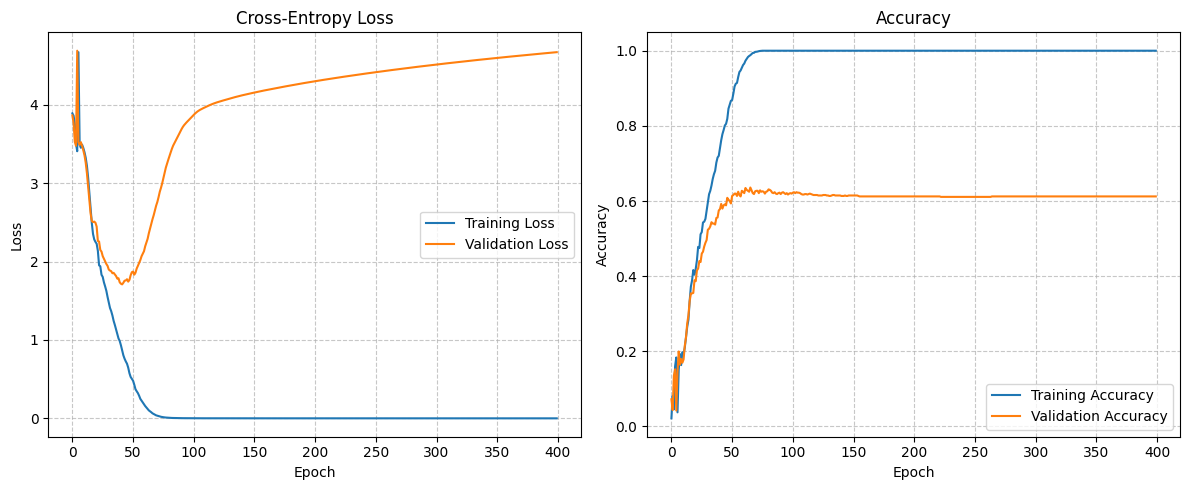

In [60]:
plot_learning_curves(history_M4)

In [61]:
models_comparison = [
    {'Modelo': 'M0', 'name': 'Modelo base implementación propia', 'model path': 'model_M0.pkl'},
    {'Modelo': 'M1', 'name': 'Mejor modelo implementación propia', 'model path': 'model_M1.pkl'},
    {'Modelo': 'M2', 'name': 'PyTorch misma arquitectura que M1', 'model path': 'model_M2.pkl'},
    {'Modelo': 'M3', 'name': 'Mejor arquitectura PyTorch', 'model path': 'model_M3.pkl'},
    {'Modelo': 'M4', 'name': 'PyTorch con overfitting', 'model path': 'model_M4.pkl'}
]

for M in models_comparison:
    model = load_model(M['model path'])
    test_acc, test_loss, test_pred = model.evaluate(X_test, y_test)
    M['Test Accuracy'] = test_acc
    M['Test Loss'] = test_loss
    
summary_df = pd.DataFrame(models_comparison).drop(columns=['model path'])

summary_df.style.set_caption("Comparación de modelos")


Model successfully loaded from modelos/model_M0.pkl
Model successfully loaded from modelos/model_M1.pkl
Model successfully loaded from modelos/model_M2.pkl
Model successfully loaded from modelos/model_M3.pkl
Model successfully loaded from modelos/model_M4.pkl


,Modelo,name,Test Accuracy,Test Loss
0,M0,Modelo base implementación propia,0.581419,1.802449
1,M1,Mejor modelo implementación propia,0.530470,2.032928
2,M2,PyTorch misma arquitectura que M1,0.605395,1.655267
3,M3,Mejor arquitectura PyTorch,0.647353,1.592074
4,M4,PyTorch con overfitting,0.605395,4.727475


### 5. Desafío
- Utilizando el modelo que considere que sea el mejor, predecir las probabilidades a-posteriori de cada clase del dataset X_COMP.npy y generar un archivo .csv con las predicciones llamado Apellido_Nombre_predicciones.csv. El archivo predicciones.csv debe tener una fila por muestra y las columnas deben ser las probabilidades a posteriori de cada clase.

In [111]:
model = PyTorchNetwork(
    layer_sizes=best_arch['layers'],
    learning_rate=0.001,
    l2_lambda=0.0005,
    dropout_rate=0.2
)

X_train, _, X_test, y_train, _, y_test = stratified_split(
    X_images / 255.0 , y_images, train_ratio=0.8, val_ratio=0.0, test_ratio=0.2, random_state=42
)

history = model.train(
    X_train, y_train, X_test, y_test,
    epochs=1000, batch_size=64,
    early_stopping_patience=15,
    verbose=2
)

save_model(model, "model_final.pkl")

Epoch: [=>                                                ] 3% - train_loss: 0.2664 - train_acc: 0.9247 - val_loss: 1.5068 - val_acc: 0.6633
Early stopping triggered at epoch 33


Training completed in 7.27 seconds
Final train loss: 0.2664, train accuracy: 0.9247
Final val loss: 1.5068, val accuracy: 0.6633
Best epoch: 18
Best val loss: 1.3991, best val accuracy: 0.6494
Model successfully saved to modelos/model_final.pkl


In [112]:
X_COMP = np.load("data/X_COMP.npy")
X_COMP = X_COMP / 255.0

model = load_model("model_final.pkl")  

probabilidades = model.forward(X_COMP)

if isinstance(probabilidades, torch.Tensor):
    probabilidades = probabilidades.detach().numpy()

columnas = [f"Clase_{i}" for i in range(probabilidades.shape[1])]

df_predicciones = pd.DataFrame(probabilidades, columns=columnas)
df_predicciones.to_csv("Ostrovsky_Eliana_predicciones.csv", index=False)

Model successfully loaded from modelos/model_final.pkl
